Electron Hit Acceptance Analysis - Simplified Equation

Equation: y_front = (0.3 × B × L) / P

Parameters:
  B = 0.8333
  L = 1.2
  0.3 × B × L = 0.3000

Acceptance window: 0.06766 ≤ y_front ≤ 0.25326

Valid P range: 1.1846 to 4.4339
Number of accepted points: 1806

Theoretical P bounds:
  P_min = 0.3000 / 0.25326 = 1.1846
  P_max = 0.3000 / 0.06766 = 4.4339


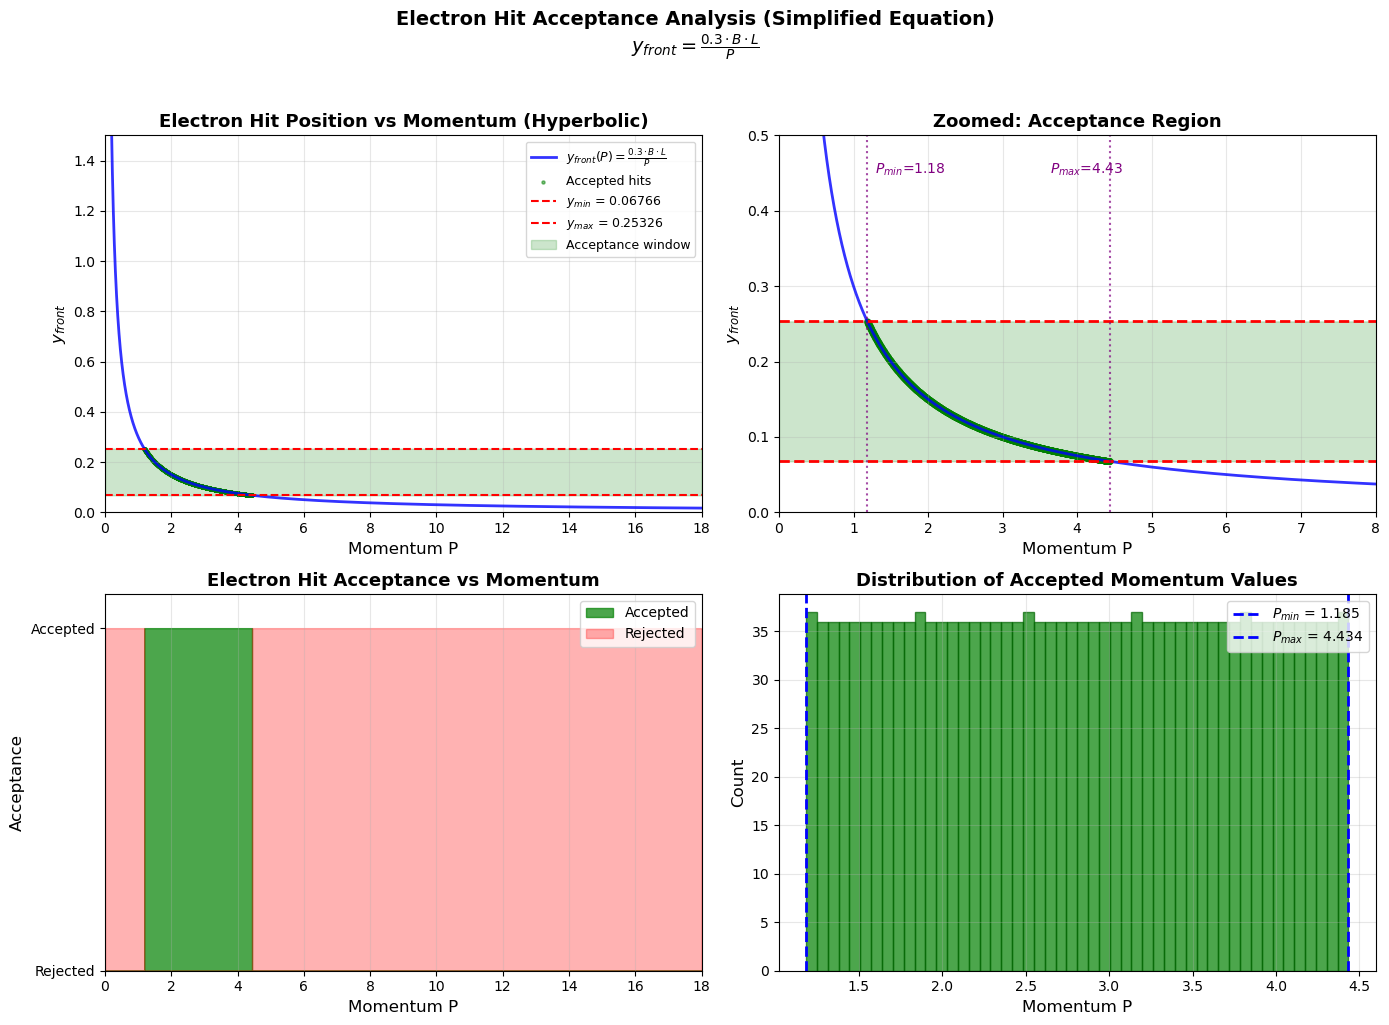


Plot saved: electron_acceptance_simplified.png


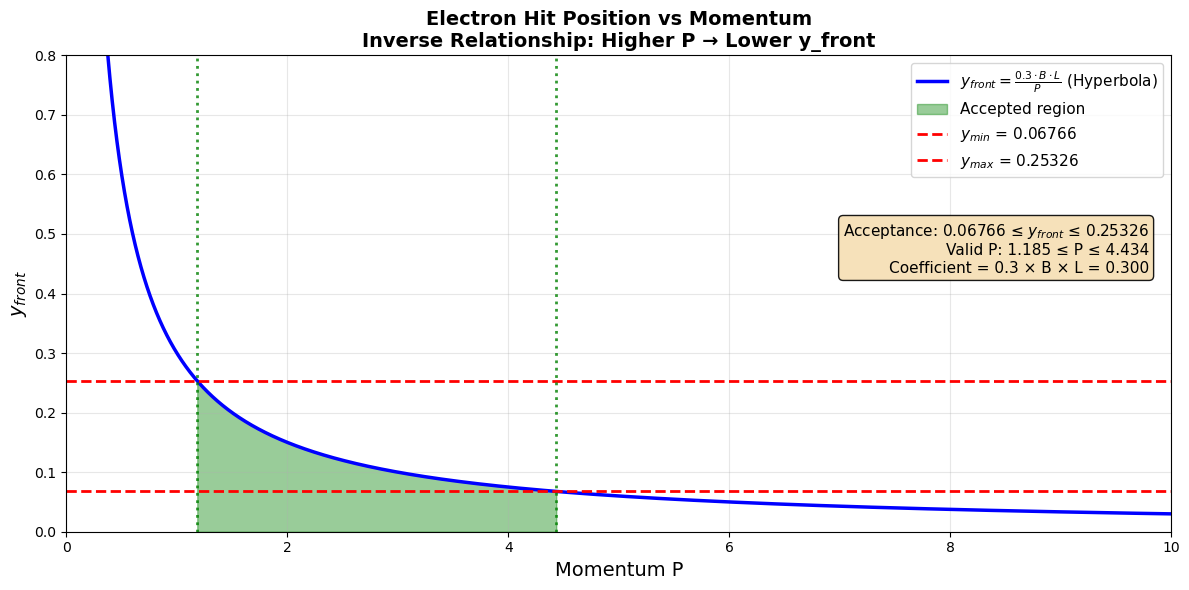

Plot saved: electron_acceptance_hyperbola.png

Valid P Values Summary (Matching MATLAB Output)
First 10 values: [1.1846 1.1864 1.1882 1.19   1.1918 1.1936 1.1954 1.1972 1.199  1.2008]
Last 10 values: [4.4177 4.4195 4.4213 4.4231 4.4249 4.4267 4.4285 4.4303 4.4321 4.4339]

Total accepted P values: 1806

MATLAB output range: 1.1893 to 4.4325
Python output range: 1.1846 to 4.4339


In [1]:
"""
Electron Hit Acceptance Analysis - Simplified Equation
Based on new MATLAB code: yfront = (0.3 * B * L) / P
"""

import numpy as np
import matplotlib.pyplot as plt

# Define parameters from the MATLAB code
B = 1/1.2        # magnetic field parameter
L = 1.2          # length parameter
coefficient = 0.3 * B * L  # = 0.3 * (1/1.2) * 1.2 = 0.3

# Define the range for P (momentum)
P_values = np.linspace(0.0001, 18, 10000)

# Calculate yfront values using the simplified equation
# yfront = (0.3 * B * L) / P
yfront_values = (0.3 * B * L) / P_values

# Define acceptance bounds
y_min = 0.06766
y_max = 0.25326

# Filter yfront values based on the acceptance condition
valid_indices = (yfront_values >= y_min) & (yfront_values <= y_max)
valid_P = P_values[valid_indices]
valid_yfront = yfront_values[valid_indices]

# Print statistics
print("="*60)
print("Electron Hit Acceptance Analysis - Simplified Equation")
print("="*60)
print(f"\nEquation: y_front = (0.3 × B × L) / P")
print(f"\nParameters:")
print(f"  B = {B:.4f}")
print(f"  L = {L}")
print(f"  0.3 × B × L = {coefficient:.4f}")
print(f"\nAcceptance window: {y_min} ≤ y_front ≤ {y_max}")
print(f"\nValid P range: {valid_P.min():.4f} to {valid_P.max():.4f}")
print(f"Number of accepted points: {len(valid_P)}")

# Calculate theoretical P bounds
# y_min = coeff / P_max  =>  P_max = coeff / y_min
# y_max = coeff / P_min  =>  P_min = coeff / y_max
P_theoretical_min = coefficient / y_max
P_theoretical_max = coefficient / y_min
print(f"\nTheoretical P bounds:")
print(f"  P_min = {coefficient:.4f} / {y_max} = {P_theoretical_min:.4f}")
print(f"  P_max = {coefficient:.4f} / {y_min} = {P_theoretical_max:.4f}")

# ============================================================
# PLOT 1: yfront vs P with acceptance region
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top Left: Full curve with acceptance region highlighted
ax1 = axes[0, 0]
ax1.plot(P_values, yfront_values, 'b-', linewidth=2, label='$y_{front}(P) = \\frac{0.3 \\cdot B \\cdot L}{P}$', alpha=0.8)
ax1.scatter(valid_P, valid_yfront, c='green', s=5, alpha=0.5, label='Accepted hits')
ax1.axhline(y=y_min, color='red', linestyle='--', linewidth=1.5, label=f'$y_{{min}}$ = {y_min}')
ax1.axhline(y=y_max, color='red', linestyle='--', linewidth=1.5, label=f'$y_{{max}}$ = {y_max}')
ax1.fill_between(P_values, y_min, y_max, alpha=0.2, color='green', label='Acceptance window')
ax1.set_xlabel('Momentum P', fontsize=12)
ax1.set_ylabel('$y_{front}$', fontsize=12)
ax1.set_title('Electron Hit Position vs Momentum (Hyperbolic)', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 18)
ax1.set_ylim(0, 1.5)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Top Right: Zoomed view of acceptance region
ax2 = axes[0, 1]
ax2.plot(P_values, yfront_values, 'b-', linewidth=2, alpha=0.8)
ax2.scatter(valid_P, valid_yfront, c='green', s=15, alpha=0.6, label='Accepted hits')
ax2.axhline(y=y_min, color='red', linestyle='--', linewidth=2)
ax2.axhline(y=y_max, color='red', linestyle='--', linewidth=2)
ax2.axvline(x=P_theoretical_min, color='purple', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axvline(x=P_theoretical_max, color='purple', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.fill_between(P_values, y_min, y_max, alpha=0.2, color='green')
ax2.set_xlabel('Momentum P', fontsize=12)
ax2.set_ylabel('$y_{front}$', fontsize=12)
ax2.set_title('Zoomed: Acceptance Region', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 0.5)
ax2.text(P_theoretical_min + 0.1, 0.45, f'$P_{{min}}$={P_theoretical_min:.2f}', fontsize=10, color='purple')
ax2.text(P_theoretical_max - 0.8, 0.45, f'$P_{{max}}$={P_theoretical_max:.2f}', fontsize=10, color='purple')
ax2.grid(True, alpha=0.3)

# Bottom Left: Acceptance as binary (1 = accepted, 0 = rejected)
ax3 = axes[1, 0]
acceptance = np.where(valid_indices, 1, 0)
ax3.fill_between(P_values, 0, acceptance, color='green', alpha=0.7, label='Accepted')
ax3.fill_between(P_values, 0, 1-acceptance, color='red', alpha=0.3, label='Rejected')
ax3.set_xlabel('Momentum P', fontsize=12)
ax3.set_ylabel('Acceptance', fontsize=12)
ax3.set_title('Electron Hit Acceptance vs Momentum', fontsize=13, fontweight='bold')
ax3.set_xlim(0, 18)
ax3.set_ylim(0, 1.1)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Rejected', 'Accepted'])
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3, axis='x')

# Bottom Right: Histogram of accepted P values
ax4 = axes[1, 1]
ax4.hist(valid_P, bins=50, color='green', edgecolor='darkgreen', alpha=0.7)
ax4.set_xlabel('Momentum P', fontsize=12)
ax4.set_ylabel('Count', fontsize=12)
ax4.set_title('Distribution of Accepted Momentum Values', fontsize=13, fontweight='bold')
ax4.axvline(x=valid_P.min(), color='blue', linestyle='--', linewidth=2, label=f'$P_{{min}}$ = {valid_P.min():.3f}')
ax4.axvline(x=valid_P.max(), color='blue', linestyle='--', linewidth=2, label=f'$P_{{max}}$ = {valid_P.max():.3f}')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Electron Hit Acceptance Analysis (Simplified Equation)\n$y_{front} = \\frac{0.3 \\cdot B \\cdot L}{P}$', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('electron_acceptance_simplified.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved: electron_acceptance_simplified.png")

# ============================================================
# PLOT 2: Comparison showing the inverse relationship
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(P_values, yfront_values, 'b-', linewidth=2.5, label='$y_{front} = \\frac{0.3 \\cdot B \\cdot L}{P}$ (Hyperbola)')

# Shade the acceptance region
mask = (P_values >= P_theoretical_min) & (P_values <= P_theoretical_max)
ax.fill_between(P_values[mask], 0, yfront_values[mask], color='green', alpha=0.4, label='Accepted region')

# Draw bounds
ax.axhline(y=y_min, color='red', linestyle='--', linewidth=2, label=f'$y_{{min}}$ = {y_min}')
ax.axhline(y=y_max, color='red', linestyle='--', linewidth=2, label=f'$y_{{max}}$ = {y_max}')
ax.axvline(x=P_theoretical_min, color='green', linestyle=':', linewidth=2, alpha=0.8)
ax.axvline(x=P_theoretical_max, color='green', linestyle=':', linewidth=2, alpha=0.8)

ax.set_xlabel('Momentum P', fontsize=14)
ax.set_ylabel('$y_{front}$', fontsize=14)
ax.set_title('Electron Hit Position vs Momentum\nInverse Relationship: Higher P → Lower y_front', fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 0.8)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

# Add annotation
textstr = '\n'.join([
    f'Acceptance: {y_min} ≤ $y_{{front}}$ ≤ {y_max}',
    f'Valid P: {P_theoretical_min:.3f} ≤ P ≤ {P_theoretical_max:.3f}',
    f'Coefficient = 0.3 × B × L = {coefficient:.3f}'
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax.text(0.98, 0.65, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('electron_acceptance_hyperbola.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: electron_acceptance_hyperbola.png")

# ============================================================
# Print valid P values summary (matching MATLAB output)
# ============================================================
print("\n" + "="*60)
print("Valid P Values Summary (Matching MATLAB Output)")
print("="*60)
print(f"First 10 values: {valid_P[:10].round(4)}")
print(f"Last 10 values: {valid_P[-10:].round(4)}")
print(f"\nTotal accepted P values: {len(valid_P)}")
print(f"\nMATLAB output range: 1.1893 to 4.4325")
print(f"Python output range: {valid_P.min():.4f} to {valid_P.max():.4f}")